<a href="https://colab.research.google.com/github/hayatkhan20/umd-urban-heat-exposure/blob/main/notebooks/06_fortyguard_heat_priority.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip -q install geopandas requests

import json
import time
from pathlib import Path

import pandas as pd
import geopandas as gpd
import requests
from google.colab import userdata


# --------------------------------------------------
# Paths
# --------------------------------------------------
REPO_DIR = Path("/content/umd-urban-heat-exposure")

BOUNDARY_PATH = (
    REPO_DIR / "data/umd_boundary_final.geojson"
)

RAW_DIR = (
    REPO_DIR / "data/raw/fortyguard"
)

OUTPUT_PATH = (
    REPO_DIR
    / "data/processed"
    / "umd_fortyguard_temperature_60m_2026-08-29.geojson"
)

RAW_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

if not BOUNDARY_PATH.exists():
    raise FileNotFoundError(BOUNDARY_PATH)

print("Found:", BOUNDARY_PATH)


# --------------------------------------------------
# Prepare UMD boundary
# --------------------------------------------------
boundary = gpd.read_file(BOUNDARY_PATH).to_crs("EPSG:26918")

if hasattr(boundary.geometry, "union_all"):
    aoi_utm = boundary.geometry.union_all()
else:
    aoi_utm = boundary.geometry.unary_union

aoi_area_km2 = aoi_utm.area / 1_000_000

# Reduce unnecessary boundary vertices
aoi_utm = aoi_utm.simplify(
    5,
    preserve_topology=True
)

aoi_wgs84 = gpd.GeoSeries(
    [aoi_utm],
    crs="EPSG:26918"
).to_crs("EPSG:4326").iloc[0]

if aoi_wgs84.geom_type == "MultiPolygon":
    aoi_wgs84 = max(
        aoi_wgs84.geoms,
        key=lambda geometry: geometry.area
    )

polygon_coordinates = [
    [
        [float(x), float(y)]
        for x, y in aoi_wgs84.exterior.coords
    ]
]

print("AOI area:", round(aoi_area_km2, 3), "km²")
print("Boundary vertices:", len(polygon_coordinates[0]))


# --------------------------------------------------
# API authentication
# --------------------------------------------------
API_KEY = userdata.get("FORTYGUARD_API_KEY")

if not API_KEY:
    raise ValueError(
        "FORTYGUARD_API_KEY is missing from Colab Secrets."
    )

HEADERS = {
    "api-key": API_KEY,
    "Content-Type": "application/json"
}

SUBMIT_URL = "https://api.fortyguard.com/v1/heatmap"
STATUS_BASE_URL = "https://api.fortyguard.com/v1/status"

ANALYSIS_DATE = "2026-08-29"

ANALYSIS_TIMES = {
    "0900": "09:00",
    "1200": "12:00",
    "1500": "15:00",
    "1800": "18:00"
}


# --------------------------------------------------
# Submit four 60 m temperature requests
# --------------------------------------------------
activities = {}

for label, analysis_time in ANALYSIS_TIMES.items():

    payload = {
        "polygon_aoi": {
            "type": "Polygon",
            "coordinates": polygon_coordinates
        },
        "date_time": {
            "start_date": ANALYSIS_DATE,
            "start_time": analysis_time,
            "filter_type": 1
        },
        "granularity": 60
    }

    response = requests.post(
        SUBMIT_URL,
        headers=HEADERS,
        json=payload,
        timeout=120
    )

    print(
        f"{label} submission HTTP status:",
        response.status_code
    )

    if not response.ok:
        print(response.text)
        response.raise_for_status()

    response_json = response.json()

    activity_id = response_json["data"]["activity_id"]

    activities[label] = {
        "time": analysis_time,
        "activity_id": activity_id
    }

    print(
        f"{label} activity ID:",
        activity_id
    )

    time.sleep(1)


# --------------------------------------------------
# Poll activity status
# --------------------------------------------------
completed_results = {}
pending = set(activities.keys())

for attempt in range(180):

    if not pending:
        break

    for label in list(pending):

        activity_id = activities[label]["activity_id"]

        response = requests.get(
            f"{STATUS_BASE_URL}/{activity_id}",
            headers=HEADERS,
            timeout=120
        )

        response.raise_for_status()
        result = response.json()

        data = result.get("data", {})

        status = (
            data.get("status")
            or result.get("status")
            or result.get("message")
            or "Unknown"
        )

        print(f"{label}: {status}")

        status_lower = str(status).lower()

        if status_lower in {
            "completed",
            "complete",
            "success",
            "succeeded"
        }:
            completed_results[label] = result
            pending.remove(label)

        elif status_lower in {
            "failed",
            "error",
            "cancelled",
            "canceled"
        }:
            raise RuntimeError(
                f"{label} request failed:\n"
                + json.dumps(result, indent=2)
            )

    if pending:
        time.sleep(5)

if pending:
    raise TimeoutError(
        f"Requests did not finish: {sorted(pending)}"
    )


# --------------------------------------------------
# Find GeoJSON FeatureCollection
# --------------------------------------------------
def find_feature_collection(value):

    if isinstance(value, str):
        try:
            return find_feature_collection(
                json.loads(value)
            )
        except (json.JSONDecodeError, TypeError):
            return None

    if isinstance(value, dict):

        if (
            value.get("type") == "FeatureCollection"
            and isinstance(value.get("features"), list)
        ):
            return value

        if "map_data" in value:
            result = find_feature_collection(
                value["map_data"]
            )
            if result is not None:
                return result

        for child in value.values():
            result = find_feature_collection(child)

            if result is not None:
                return result

    if isinstance(value, list):

        for child in value:
            result = find_feature_collection(child)

            if result is not None:
                return result

    return None


# --------------------------------------------------
# Save and combine temperature results
# --------------------------------------------------
temperature_layers = []

for label, result in completed_results.items():

    raw_path = (
        RAW_DIR
        / f"umd_temperature_60m_{ANALYSIS_DATE}_{label}_raw.json"
    )

    with open(raw_path, "w", encoding="utf-8") as file:
        json.dump(result, file, indent=2)

    feature_collection = find_feature_collection(
        result
    )

    if feature_collection is None:
        raise ValueError(
            f"No GeoJSON FeatureCollection found for {label}. "
            f"Inspect {raw_path}"
        )

    layer = gpd.GeoDataFrame.from_features(
        feature_collection["features"],
        crs="EPSG:4326"
    )

    layer = layer[
        layer.geometry.notna()
        & ~layer.geometry.is_empty
    ].copy()

    layer["analysis_date"] = ANALYSIS_DATE
    layer["analysis_time"] = ANALYSIS_TIMES[label]
    layer["time_code"] = label

    temperature_layers.append(layer)

    print(
        f"{label} temperature tiles:",
        len(layer)
    )


temperature = gpd.GeoDataFrame(
    pd.concat(
        temperature_layers,
        ignore_index=True
    ),
    crs="EPSG:4326"
)

temperature.to_file(
    OUTPUT_PATH,
    driver="GeoJSON"
)


# --------------------------------------------------
# Validate output
# --------------------------------------------------
print("\n--- FORTYGUARD 60 M TEMPERATURE OUTPUT ---")
print("Total records:", len(temperature))
print("CRS:", temperature.crs)
print("Columns:")
print(temperature.columns.tolist())

print("\nRecords by time:")
print(
    temperature.groupby("analysis_time")
    .size()
)

numeric_columns = temperature.select_dtypes(
    include="number"
).columns.tolist()

if numeric_columns:
    print("\nNumeric-field statistics:")
    print(
        temperature[numeric_columns]
        .describe()
        .T
        .round(3)
    )

print("\nCreated:", OUTPUT_PATH)
print(
    "File size:",
    round(OUTPUT_PATH.stat().st_size / 1_048_576, 2),
    "MiB"
)

Found: /content/umd-urban-heat-exposure/data/umd_boundary_final.geojson
AOI area: 10.945 km²
Boundary vertices: 37
0900 submission HTTP status: 200
0900 activity ID: a8974cfa-126b-451c-b864-07baca5bba5e
1200 submission HTTP status: 200
1200 activity ID: ec35be60-05e2-4792-85a1-99331037c4f5
1500 submission HTTP status: 200
1500 activity ID: e9534443-2dba-4a69-b540-297266acd769
1800 submission HTTP status: 200
1800 activity ID: 4e4dbb69-2725-40cd-93d7-a28ec751e796
0900: Processing
1500: Processing
1800: Processing
1200: Processing
0900: Completed
1500: Processing
1800: Completed
1200: Completed
1500: Completed
0900 temperature tiles: 3022
1800 temperature tiles: 3022
1200 temperature tiles: 3022
1500 temperature tiles: 3022

--- FORTYGUARD 60 M TEMPERATURE OUTPUT ---
Total records: 12088
CRS: EPSG:4326
Columns:
['geometry', 'tile_id', 'average_temperature', 'min_temperature', 'max_temperature', 'analysis_date', 'analysis_time', 'time_code']

Records by time:
analysis_time
09:00    3022
1

In [8]:
from pathlib import Path
import numpy as np
import geopandas as gpd

TEMP_PATH = Path(
    "/content/umd-urban-heat-exposure/"
    "data/processed/"
    "umd_fortyguard_temperature_60m_2026-08-29.geojson"
)

temperature = gpd.read_file(TEMP_PATH)

time_summary = (
    temperature
    .groupby("analysis_time")["average_temperature"]
    .agg(
        tiles="size",
        unique_temperatures="nunique",
        minimum="min",
        mean="mean",
        median="median",
        maximum="max",
        spatial_std="std"
    )
    .round(3)
)

print("--- TEMPERATURE VARIATION BY TIME ---")
print(time_summary)

same_values = (
    np.isclose(
        temperature["average_temperature"],
        temperature["min_temperature"]
    )
    & np.isclose(
        temperature["average_temperature"],
        temperature["max_temperature"]
    )
)

print(
    "\nTiles where average = minimum = maximum:",
    int(same_values.sum()),
    "of",
    len(temperature)
)

tile_time_counts = (
    temperature
    .groupby("tile_id")["analysis_time"]
    .nunique()
)

print(
    "Tiles represented at all four times:",
    int((tile_time_counts == 4).sum()),
    "of",
    tile_time_counts.size
)

--- TEMPERATURE VARIATION BY TIME ---
               tiles  unique_temperatures  minimum    mean  median  maximum  \
analysis_time                                                                 
09:00:00        3022                 1396   21.966  22.298  22.303   22.419   
12:00:00        3022                 1542   26.217  27.109  27.148   27.362   
15:00:00        3022                 1967   29.423  30.746  30.808   31.069   
18:00:00        3022                 1734   29.106  30.195  30.251   30.460   

               spatial_std  
analysis_time               
09:00:00             0.086  
12:00:00             0.214  
15:00:00             0.316  
18:00:00             0.251  

Tiles where average = minimum = maximum: 12088 of 12088
Tiles represented at all four times: 3022 of 3022


In [17]:
from pathlib import Path
import shutil
import subprocess

REPO_DIR = Path("/content/umd-urban-heat-exposure")

temperature_path = (
    REPO_DIR
    / "data/processed"
    / "umd_fortyguard_temperature_60m_2026-08-29.geojson"
)

# Protect the locally generated temperature file before pulling
if temperature_path.exists():

    local_backup = Path(
        "/content/umd_fortyguard_temperature_local_backup.geojson"
    )

    shutil.copy2(
        temperature_path,
        local_backup
    )

    temperature_path.unlink()

    print("Temporary local backup:", local_backup)

pull = subprocess.run(
    ["git", "pull", "--ff-only", "origin", "main"],
    cwd=REPO_DIR,
    text=True,
    capture_output=True
)

print(pull.stdout)
print(pull.stderr)

if pull.returncode != 0:
    raise RuntimeError("Git pull failed.")

exposure_path = (
    REPO_DIR
    / "data/processed"
    / "umd_building_solar_exposure_2026-08-29.geojson"
)

print("Exposure found:", exposure_path.exists())
print("Temperature found:", temperature_path.exists())

Temporary local backup: /content/umd_fortyguard_temperature_local_backup.geojson
Updating 084592c..bc34409
Fast-forward
 .../umd_building_solar_exposure_2026-08-29.csv     |  3695 ++++++
 .../umd_building_solar_exposure_2026-08-29.geojson |  3701 ++++++
 .../umd_buildings_with_canopy_distance.geojson     |  3701 ++++++
 data/processed/umd_distance_to_canopy_1m.tif       |   Bin 0 -> 9783327 bytes
 data/processed/umd_exposure_summary_2026-08-29.csv |     6 +
 ...d_fortyguard_temperature_60m_2026-08-29.geojson | 12095 +++++++++++++++++++
 data/processed/umd_sun_positions_2026-08-29.csv    |    27 +
 outputs/figures/umd_building_envelope_exposure.png |   Bin 0 -> 2230162 bytes
 8 files changed, 23225 insertions(+)
 create mode 100644 data/processed/umd_building_solar_exposure_2026-08-29.csv
 create mode 100644 data/processed/umd_building_solar_exposure_2026-08-29.geojson
 create mode 100644 data/processed/umd_buildings_with_canopy_distance.geojson
 create mode 100644 data/processed/umd_di

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd


# --------------------------------------------------
# Paths
# --------------------------------------------------
REPO_DIR = Path("/content/umd-urban-heat-exposure")

BUILDINGS_PATH = (
    REPO_DIR
    / "data/processed"
    / "umd_building_solar_exposure_2026-08-29.geojson"
)

TEMPERATURE_PATH = (
    REPO_DIR
    / "data/processed"
    / "umd_fortyguard_temperature_60m_2026-08-29.geojson"
)

OUTPUT_GEOJSON = (
    REPO_DIR
    / "data/processed"
    / "umd_building_temperature_exposure_2026-08-29.geojson"
)

OUTPUT_CSV = (
    REPO_DIR
    / "data/processed"
    / "umd_building_temperature_exposure_2026-08-29.csv"
)

for path in [BUILDINGS_PATH, TEMPERATURE_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

    print("Found:", path)


# --------------------------------------------------
# Load data
# --------------------------------------------------
buildings = gpd.read_file(
    BUILDINGS_PATH
).to_crs("EPSG:26918")

temperature = gpd.read_file(
    TEMPERATURE_PATH
).to_crs("EPSG:26918")

buildings = buildings.reset_index(drop=True).copy()

if "building_uid" not in buildings.columns:
    buildings["building_uid"] = (
        np.arange(len(buildings)) + 1
    )

if not buildings["building_uid"].is_unique:
    raise ValueError("building_uid is not unique.")

temperature["analysis_time_text"] = (
    temperature["analysis_time"]
    .astype(str)
    .str[:5]
)

temperature["average_temperature"] = pd.to_numeric(
    temperature["average_temperature"],
    errors="coerce"
)


# --------------------------------------------------
# Area-weighted building temperatures
# --------------------------------------------------
TIME_MAPPING = {
    "0900": "09:00",
    "1200": "12:00",
    "1500": "15:00",
    "1800": "18:00"
}

result = buildings.copy()

building_geometry = buildings[
    ["building_uid", "geometry"]
].copy()

for code, time_text in TIME_MAPPING.items():

    print(f"\nProcessing {time_text}...")

    tiles = temperature[
        temperature["analysis_time_text"] == time_text
    ][
        ["average_temperature", "geometry"]
    ].copy()

    if tiles.empty:
        raise ValueError(
            f"No temperature tiles found for {time_text}"
        )

    intersections = gpd.overlay(
        building_geometry,
        tiles,
        how="intersection",
        keep_geom_type=False
    )

    intersections["intersection_area_m2"] = (
        intersections.geometry.area
    )

    intersections = intersections[
        intersections["intersection_area_m2"] > 0
    ].copy()

    intersections["weighted_temperature"] = (
        intersections["average_temperature"]
        * intersections["intersection_area_m2"]
    )

    weighted = (
        intersections
        .groupby("building_uid")
        .agg(
            weighted_sum=(
                "weighted_temperature",
                "sum"
            ),
            intersected_area_m2=(
                "intersection_area_m2",
                "sum"
            )
        )
    )

    weighted["building_temperature"] = (
        weighted["weighted_sum"]
        / weighted["intersected_area_m2"]
    )

    field_name = f"temperature_c_{code}"

    result[field_name] = (
        result["building_uid"]
        .map(weighted["building_temperature"])
    )

    directly_matched = result[field_name].notna()
    missing_ids = result.loc[
        ~directly_matched,
        "building_uid"
    ]

    # Fallback: nearest temperature tile
    if len(missing_ids) > 0:

        missing_buildings = buildings[
            buildings["building_uid"].isin(
                missing_ids
            )
        ][
            ["building_uid", "geometry"]
        ].copy()

        missing_buildings.geometry = (
            missing_buildings.geometry
            .representative_point()
        )

        nearest = gpd.sjoin_nearest(
            missing_buildings,
            tiles,
            how="left",
            distance_col="temperature_tile_distance_m"
        )

        nearest_values = (
            nearest
            .groupby("building_uid")[
                "average_temperature"
            ]
            .mean()
        )

        fallback_mask = result[field_name].isna()

        result.loc[fallback_mask, field_name] = (
            result.loc[
                fallback_mask,
                "building_uid"
            ].map(nearest_values)
        )

    print(
        "  Area-weighted matches:",
        int(directly_matched.sum())
    )

    print(
        "  Nearest-tile fallbacks:",
        int((~directly_matched).sum())
    )

    print(
        "  Remaining missing:",
        int(result[field_name].isna().sum())
    )


# --------------------------------------------------
# Four-time temperature summaries
# --------------------------------------------------
temperature_fields = [
    "temperature_c_0900",
    "temperature_c_1200",
    "temperature_c_1500",
    "temperature_c_1800"
]

result["mean_temperature_c"] = (
    result[temperature_fields].mean(axis=1)
)

result["maximum_temperature_c"] = (
    result[temperature_fields].max(axis=1)
)

result["minimum_temperature_c"] = (
    result[temperature_fields].min(axis=1)
)

result["temperature_range_c"] = (
    result["maximum_temperature_c"]
    - result["minimum_temperature_c"]
)


# --------------------------------------------------
# Save
# --------------------------------------------------
result.to_file(
    OUTPUT_GEOJSON,
    driver="GeoJSON"
)

result.drop(columns="geometry").to_csv(
    OUTPUT_CSV,
    index=False
)


# --------------------------------------------------
# Validation
# --------------------------------------------------
print("\n--- BUILDING TEMPERATURE JOIN ---")
print("Buildings:", len(result))

print(
    "Buildings with all four temperatures:",
    int(result[temperature_fields].notna().all(axis=1).sum())
)

print("\nBuilding-temperature statistics:")
print(
    result[
        temperature_fields
        + [
            "mean_temperature_c",
            "maximum_temperature_c",
            "temperature_range_c"
        ]
    ]
    .describe()
    .T
    .round(3)
)

print("\nCreated:", OUTPUT_GEOJSON)
print("Created:", OUTPUT_CSV)

Found: /content/umd-urban-heat-exposure/data/processed/umd_building_solar_exposure_2026-08-29.geojson
Found: /content/umd-urban-heat-exposure/data/processed/umd_fortyguard_temperature_60m_2026-08-29.geojson

Processing 09:00...
  Area-weighted matches: 3629
  Nearest-tile fallbacks: 65
  Remaining missing: 0

Processing 12:00...
  Area-weighted matches: 3629
  Nearest-tile fallbacks: 65
  Remaining missing: 0

Processing 15:00...
  Area-weighted matches: 3629
  Nearest-tile fallbacks: 65
  Remaining missing: 0

Processing 18:00...
  Area-weighted matches: 3629
  Nearest-tile fallbacks: 65
  Remaining missing: 0

--- BUILDING TEMPERATURE JOIN ---
Buildings: 3694
Buildings with all four temperatures: 3694

Building-temperature statistics:
                        count    mean    std     min     25%     50%     75%  \
temperature_c_0900     3694.0  22.294  0.089  21.976  22.283  22.313  22.353   
temperature_c_1200     3694.0  27.078  0.208  26.240  27.123  27.141  27.153   
temperature_c

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

from scipy.stats import pearsonr, spearmanr


REPO_DIR = Path("/content/umd-urban-heat-exposure")

INPUT_PATH = (
    REPO_DIR
    / "data/processed"
    / "umd_building_temperature_exposure_2026-08-29.geojson"
)

OUTPUT_PATH = (
    REPO_DIR
    / "data/processed"
    / "umd_temperature_exposure_correlations_2026-08-29.csv"
)

buildings = gpd.read_file(INPUT_PATH)


# --------------------------------------------------
# Safe correlation function
# --------------------------------------------------
def calculate_correlations(data, x_column, y_column):

    valid = data[
        [x_column, y_column]
    ].apply(
        pd.to_numeric,
        errors="coerce"
    ).dropna()

    if (
        len(valid) < 3
        or valid[x_column].nunique() < 2
        or valid[y_column].nunique() < 2
    ):
        return np.nan, np.nan

    pearson = pearsonr(
        valid[x_column],
        valid[y_column]
    ).statistic

    spearman = spearmanr(
        valid[x_column],
        valid[y_column]
    ).statistic

    return pearson, spearman


def upper_lower_temperature_difference(
    data,
    variable,
    temperature_column
):

    valid = data[
        [variable, temperature_column]
    ].apply(
        pd.to_numeric,
        errors="coerce"
    ).dropna()

    lower_limit = valid[variable].quantile(0.25)
    upper_limit = valid[variable].quantile(0.75)

    low_group = valid.loc[
        valid[variable] <= lower_limit,
        temperature_column
    ]

    high_group = valid.loc[
        valid[variable] >= upper_limit,
        temperature_column
    ]

    return high_group.mean() - low_group.mean()


# --------------------------------------------------
# Same-time analysis
# --------------------------------------------------
records = []

for code, time_label in [
    ("0900", "09:00"),
    ("1200", "12:00"),
    ("1500", "15:00"),
    ("1800", "18:00")
]:

    temperature_column = f"temperature_c_{code}"
    exposure_column = f"exposure_fraction_{code}"
    solar_column = f"solar_index_{code}"
    shade_column = f"tree_shade_fraction_{code}"

    exposure_pearson, exposure_spearman = (
        calculate_correlations(
            buildings,
            exposure_column,
            temperature_column
        )
    )

    solar_pearson, solar_spearman = (
        calculate_correlations(
            buildings,
            solar_column,
            temperature_column
        )
    )

    shade_pearson, shade_spearman = (
        calculate_correlations(
            buildings,
            shade_column,
            temperature_column
        )
    )

    overlap_pearson, overlap_spearman = (
        calculate_correlations(
            buildings,
            "canopy_overlap_pct",
            temperature_column
        )
    )

    distance_pearson, distance_spearman = (
        calculate_correlations(
            buildings,
            "nearest_canopy_distance_m",
            temperature_column
        )
    )

    records.append(
        {
            "time": time_label,

            "temperature_exposure_pearson":
                exposure_pearson,

            "temperature_exposure_spearman":
                exposure_spearman,

            "temperature_solar_index_pearson":
                solar_pearson,

            "temperature_solar_index_spearman":
                solar_spearman,

            "temperature_tree_shade_pearson":
                shade_pearson,

            "temperature_tree_shade_spearman":
                shade_spearman,

            "temperature_canopy_overlap_pearson":
                overlap_pearson,

            "temperature_canopy_overlap_spearman":
                overlap_spearman,

            "temperature_canopy_distance_pearson":
                distance_pearson,

            "temperature_canopy_distance_spearman":
                distance_spearman,

            "high_minus_low_exposure_temperature_c":
                upper_lower_temperature_difference(
                    buildings,
                    exposure_column,
                    temperature_column
                ),

            "high_minus_low_tree_shade_temperature_c":
                upper_lower_temperature_difference(
                    buildings,
                    shade_column,
                    temperature_column
                )
        }
    )


correlation_summary = pd.DataFrame(records)

numeric_columns = correlation_summary.columns[
    correlation_summary.columns != "time"
]

correlation_summary[numeric_columns] = (
    correlation_summary[numeric_columns]
    .round(4)
)

correlation_summary.to_csv(
    OUTPUT_PATH,
    index=False
)

print("--- TEMPERATURE–EXPOSURE RELATIONSHIPS ---")
display(correlation_summary)

print("\nCreated:", OUTPUT_PATH)

--- TEMPERATURE–EXPOSURE RELATIONSHIPS ---


,time,temperature_exposure_pearson,temperature_exposure_spearman,temperature_solar_index_pearson,temperature_solar_index_spearman,temperature_tree_shade_pearson,temperature_tree_shade_spearman,temperature_canopy_overlap_pearson,temperature_canopy_overlap_spearman,temperature_canopy_distance_pearson,temperature_canopy_distance_spearman,high_minus_low_exposure_temperature_c,high_minus_low_tree_shade_temperature_c
0,09:00,0.0971,0.0418,0.0874,0.0283,-0.1045,-0.0549,-0.0695,-0.0562,0.0558,0.0929,0.0208,-0.0259
1,12:00,0.0922,0.0989,0.0736,0.0759,-0.1025,-0.1014,-0.0758,-0.0853,0.0605,0.0897,0.0475,-0.0657
2,15:00,0.0864,0.0541,0.0724,0.0230,-0.0989,-0.0844,-0.0756,-0.0747,0.0562,0.1150,0.0686,-0.0894
3,18:00,0.0974,0.0770,0.1106,0.0985,-0.1073,-0.0897,-0.0784,-0.0939,0.0522,0.1373,0.0721,-0.0823



Created: /content/umd-urban-heat-exposure/data/processed/umd_temperature_exposure_correlations_2026-08-29.csv


In [21]:
!pip -q install rasterstats

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from rasterstats import zonal_stats
from scipy.stats import spearmanr


REPO_DIR = Path("/content/umd-urban-heat-exposure")

BUILDING_PATH = (
    REPO_DIR
    / "data/processed"
    / "umd_building_temperature_exposure_2026-08-29.geojson"
)

LAI_PATH = (
    REPO_DIR
    / "data/processed"
    / "umd_lai_summer_2026_20m.tif"
)

OUTPUT_GEOJSON = (
    REPO_DIR
    / "data/processed"
    / "umd_building_heat_analysis_2026-08-29.geojson"
)

OUTPUT_CSV = (
    REPO_DIR
    / "data/processed"
    / "umd_building_heat_analysis_2026-08-29.csv"
)

for path in [BUILDING_PATH, LAI_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

    print("Found:", path)


# --------------------------------------------------
# Load buildings and LAI information
# --------------------------------------------------
buildings = gpd.read_file(BUILDING_PATH)

with rasterio.open(LAI_PATH) as src:
    lai_crs = src.crs
    lai_nodata = src.nodata
    lai_resolution = src.res

print("LAI CRS:", lai_crs)
print("LAI resolution:", lai_resolution)
print("LAI NoData:", lai_nodata)

buildings_lai_crs = buildings.to_crs(lai_crs)


# --------------------------------------------------
# 30 m surrounding area, excluding each building
# --------------------------------------------------
surrounding_areas = (
    buildings_lai_crs.geometry.buffer(30)
    .difference(buildings_lai_crs.geometry)
)

lai_statistics = zonal_stats(
    surrounding_areas,
    LAI_PATH,
    stats=["mean", "median", "count"],
    nodata=lai_nodata,
    all_touched=False
)

buildings["surrounding_lai_mean_30m"] = [
    record["mean"]
    for record in lai_statistics
]

buildings["surrounding_lai_median_30m"] = [
    record["median"]
    for record in lai_statistics
]

buildings["surrounding_lai_pixel_count_30m"] = [
    record["count"]
    for record in lai_statistics
]


# --------------------------------------------------
# LAI-temperature relationship
# --------------------------------------------------
valid = buildings[
    [
        "surrounding_lai_mean_30m",
        "mean_temperature_c",
        "maximum_temperature_c"
    ]
].apply(
    pd.to_numeric,
    errors="coerce"
).dropna()

lai_mean_temperature_correlation = spearmanr(
    valid["surrounding_lai_mean_30m"],
    valid["mean_temperature_c"]
).statistic

lai_peak_temperature_correlation = spearmanr(
    valid["surrounding_lai_mean_30m"],
    valid["maximum_temperature_c"]
).statistic


# --------------------------------------------------
# Save
# --------------------------------------------------
buildings.to_file(
    OUTPUT_GEOJSON,
    driver="GeoJSON"
)

buildings.drop(columns="geometry").to_csv(
    OUTPUT_CSV,
    index=False
)


# --------------------------------------------------
# Validation
# --------------------------------------------------
print("\n--- BUILDING SURROUNDING LAI ---")
print("Buildings:", len(buildings))

print(
    "Buildings with LAI:",
    int(
        buildings[
            "surrounding_lai_mean_30m"
        ].notna().sum()
    )
)

print("\nSurrounding LAI statistics:")
print(
    buildings[
        "surrounding_lai_mean_30m"
    ].describe().round(3)
)

print(
    "\nLAI vs mean temperature Spearman:",
    round(lai_mean_temperature_correlation, 4)
)

print(
    "LAI vs peak temperature Spearman:",
    round(lai_peak_temperature_correlation, 4)
)

print("\nCreated:", OUTPUT_GEOJSON)
print("Created:", OUTPUT_CSV)

Found: /content/umd-urban-heat-exposure/data/processed/umd_building_temperature_exposure_2026-08-29.geojson
Found: /content/umd-urban-heat-exposure/data/processed/umd_lai_summer_2026_20m.tif
LAI CRS: EPSG:26918
LAI resolution: (20.0, 20.0)
LAI NoData: None


/usr/local/lib/python3.13/dist-packages/rasterstats/io.py:437: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(



--- BUILDING SURROUNDING LAI ---
Buildings: 3694
Buildings with LAI: 3694

Surrounding LAI statistics:
count    3694.000
mean        1.153
std         0.604
min         0.000
25%         0.799
50%         1.254
75%         1.565
max         3.066
Name: surrounding_lai_mean_30m, dtype: float64

LAI vs mean temperature Spearman: -0.1249
LAI vs peak temperature Spearman: -0.1164

Created: /content/umd-urban-heat-exposure/data/processed/umd_building_heat_analysis_2026-08-29.geojson
Created: /content/umd-urban-heat-exposure/data/processed/umd_building_heat_analysis_2026-08-29.csv


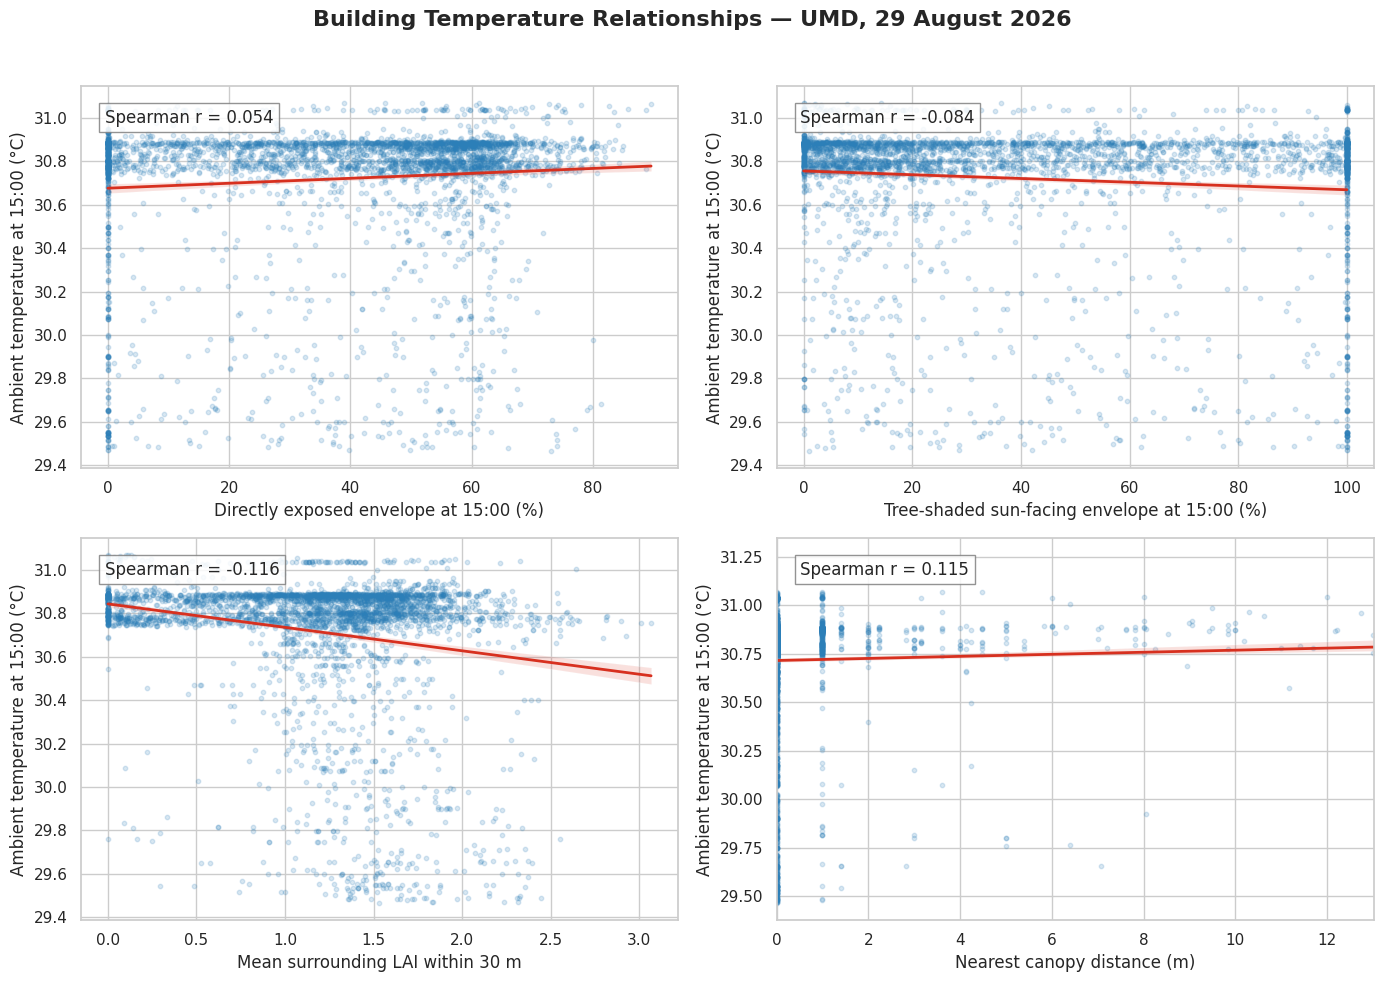

Created: /content/umd-urban-heat-exposure/outputs/figures/umd_temperature_relationships.png


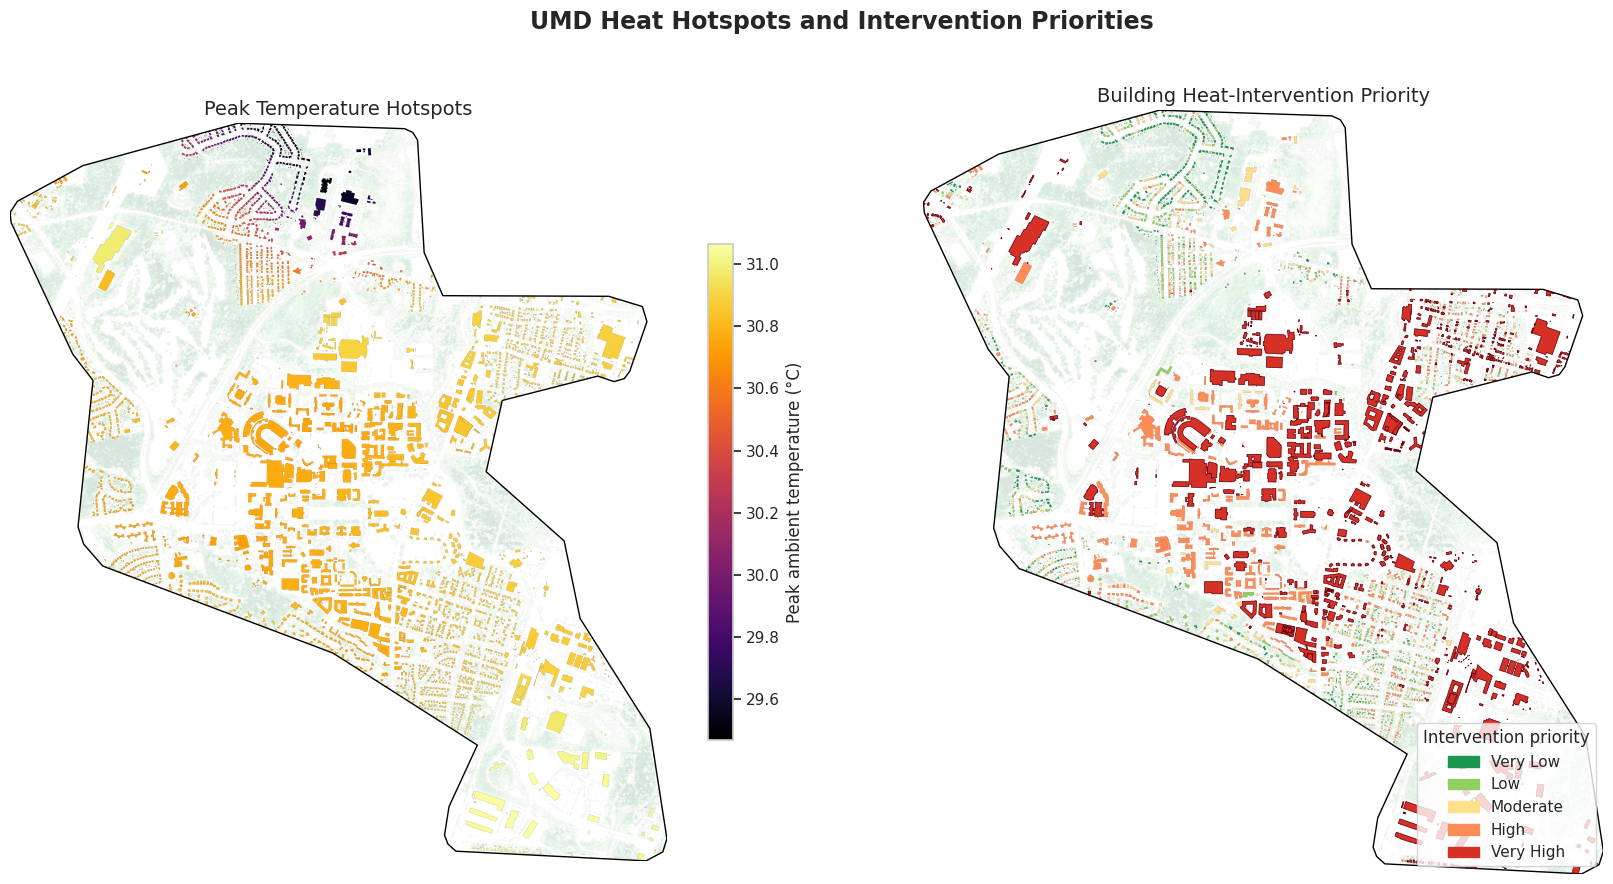

Created: /content/umd-urban-heat-exposure/outputs/figures/umd_heat_priority_hotspots.png

--- HEAT PRIORITY SUMMARY ---
priority_class
Very High    739
High         739
Moderate     738
Low          739
Very Low     739
Name: count, dtype: int64

Priority score statistics:
count    3694.00
mean       50.01
std        20.99
min         3.78
25%        34.86
50%        49.12
75%        65.75
max        98.06
Name: heat_priority_score, dtype: float64


,id,heat_priority_score,priority_class,maximum_temperature_c,mean_solar_exposure_index,mean_tree_shade_fraction,surrounding_lai_mean_30m,nearest_canopy_distance_m,recommended_action
1793,37b161f1-4cf8-4920-b584-61df8c333708,98.057661,Very High,31.041991,0.4895,0.0432,0.000000,1.00,Priority tree planting and roof/facade cooling
2227,0740bbf3-5669-4bbf-819d-229aba2b5938,97.392167,Very High,31.033501,0.5186,0.0102,0.064315,0.00,Priority tree planting and roof/facade cooling
2225,16f457fe-796b-44e0-84e7-21f4a0c914ab,97.292907,Very High,31.056179,0.4492,0.0156,0.148706,1.00,Priority tree planting and roof/facade cooling
969,d1d87822-91e2-4c71-b46e-5ff520b2ba0c,96.904891,Very High,30.905785,0.4575,0.0054,0.000000,1.00,Priority tree planting and roof/facade cooling
1794,f83fa749-e9f6-4e75-aca5-b3caab219aac,96.760513,Very High,31.047952,0.3833,0.0185,0.057846,1.00,Priority tree planting and roof/facade cooling
2321,c2d89875-a8c0-43f8-b5b9-7f492a3d92e2,96.589063,Very High,31.043300,0.3849,0.0000,0.192664,35.44,Priority tree planting and roof/facade cooling
2233,195c8654-a53e-40c7-a1d6-6e6f40fc370d,96.390543,Very High,31.060475,0.4103,0.0840,0.036383,0.00,Priority tree planting and roof/facade cooling
2330,7c024f46-cf48-4c71-ad83-e7744be1c730,96.336401,Very High,31.064051,0.4173,0.0802,0.070898,0.00,Priority tree planting and roof/facade cooling
2226,7d4089c4-7348-4dfc-8b62-372eaafe59c4,96.250677,Very High,31.061931,0.4742,0.1580,0.000000,1.00,Priority tree planting and roof/facade cooling
2235,6886f32f-d5ff-44db-ac15-a34dc38f443b,95.851381,Very High,31.041552,0.3282,0.0000,0.000000,50.61,Priority tree planting and roof/facade cooling



Created: /content/umd-urban-heat-exposure/data/processed/umd_building_heat_priority_2026-08-29.geojson
Created: /content/umd-urban-heat-exposure/data/processed/umd_building_heat_priority_2026-08-29.csv


In [22]:
!pip -q install seaborn

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import spearmanr
from rasterio.transform import array_bounds
from matplotlib.colors import ListedColormap


# --------------------------------------------------
# Paths
# --------------------------------------------------
REPO_DIR = Path("/content/umd-urban-heat-exposure")

INPUT_PATH = (
    REPO_DIR
    / "data/processed"
    / "umd_building_heat_analysis_2026-08-29.geojson"
)

CANOPY_PATH = (
    REPO_DIR
    / "data/processed"
    / "umd_canopy_height_naip_chm_1m.tif"
)

BOUNDARY_PATH = (
    REPO_DIR
    / "data/umd_boundary_final.geojson"
)

OUTPUT_GEOJSON = (
    REPO_DIR
    / "data/processed"
    / "umd_building_heat_priority_2026-08-29.geojson"
)

OUTPUT_CSV = (
    REPO_DIR
    / "data/processed"
    / "umd_building_heat_priority_2026-08-29.csv"
)

FIGURE_DIRECTORY = (
    REPO_DIR / "outputs/figures"
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

RELATIONSHIP_FIGURE = (
    FIGURE_DIRECTORY
    / "umd_temperature_relationships.png"
)

HOTSPOT_FIGURE = (
    FIGURE_DIRECTORY
    / "umd_heat_priority_hotspots.png"
)


# --------------------------------------------------
# Load analysis
# --------------------------------------------------
buildings = (
    gpd.read_file(INPUT_PATH)
    .to_crs("EPSG:26918")
)

required_columns = [
    "maximum_temperature_c",
    "temperature_c_1500",
    "mean_solar_exposure_index",
    "exposure_fraction_1500",
    "mean_tree_shade_fraction",
    "tree_shade_fraction_1500",
    "surrounding_lai_mean_30m",
    "nearest_canopy_distance_m"
]

for column in required_columns:
    buildings[column] = pd.to_numeric(
        buildings[column],
        errors="coerce"
    )

    if buildings[column].isna().any():
        raise ValueError(
            f"Missing values found in {column}"
        )


# --------------------------------------------------
# Transparent priority components
# --------------------------------------------------
buildings["heat_component"] = (
    buildings["maximum_temperature_c"]
    .rank(pct=True)
)

buildings["solar_exposure_component"] = (
    buildings["mean_solar_exposure_index"]
    .rank(pct=True)
)

buildings["tree_shade_deficit"] = (
    1 - buildings["mean_tree_shade_fraction"]
)

buildings["tree_shade_deficit_component"] = (
    buildings["tree_shade_deficit"]
    .rank(pct=True)
)

buildings["lai_deficit_component"] = (
    1
    - buildings["surrounding_lai_mean_30m"]
    .rank(pct=True)
)

buildings["vegetation_deficit_component"] = (
    (
        buildings["tree_shade_deficit_component"]
        + buildings["lai_deficit_component"]
    )
    / 2
)

buildings["heat_priority_score"] = (
    (
        buildings["heat_component"]
        + buildings["solar_exposure_component"]
        + buildings["vegetation_deficit_component"]
    )
    / 3
    * 100
)


# --------------------------------------------------
# Priority classes
# --------------------------------------------------
priority_labels = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

buildings["priority_class"] = (
    pd.qcut(
        buildings[
            "heat_priority_score"
        ].rank(method="first"),
        q=5,
        labels=priority_labels
    )
    .astype(str)
)

action_mapping = {
    "Very High":
        "Priority tree planting and roof/facade cooling",

    "High":
        "Targeted shade trees and cool-roof assessment",

    "Moderate":
        "Monitor and improve local shade",

    "Low":
        "Maintain existing mitigation",

    "Very Low":
        "Preserve existing canopy"
}

buildings["recommended_action"] = (
    buildings["priority_class"]
    .map(action_mapping)
)


# --------------------------------------------------
# Save priority dataset
# --------------------------------------------------
output = buildings.to_crs("EPSG:4326")

output.to_file(
    OUTPUT_GEOJSON,
    driver="GeoJSON"
)

output.drop(columns="geometry").to_csv(
    OUTPUT_CSV,
    index=False
)


# --------------------------------------------------
# Relationship graphs
# --------------------------------------------------
sns.set_theme(style="whitegrid")

figure, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

relationship_specs = [
    (
        "exposure_fraction_1500",
        "Directly exposed envelope at 15:00 (%)",
        True
    ),
    (
        "tree_shade_fraction_1500",
        "Tree-shaded sun-facing envelope at 15:00 (%)",
        True
    ),
    (
        "surrounding_lai_mean_30m",
        "Mean surrounding LAI within 30 m",
        False
    ),
    (
        "nearest_canopy_distance_m",
        "Nearest canopy distance (m)",
        False
    )
]

for ax, (
    x_column,
    x_label,
    convert_to_percent
) in zip(axes.flat, relationship_specs):

    plotting_data = buildings[
        [x_column, "temperature_c_1500"]
    ].dropna().copy()

    x_values = plotting_data[x_column]

    if convert_to_percent:
        x_values = x_values * 100

    correlation = spearmanr(
        plotting_data[x_column],
        plotting_data["temperature_c_1500"]
    ).statistic

    sns.regplot(
        x=x_values,
        y=plotting_data["temperature_c_1500"],
        ax=ax,
        scatter_kws={
            "s": 10,
            "alpha": 0.18,
            "color": "#2c7fb8"
        },
        line_kws={
            "color": "#d7301f",
            "linewidth": 2
        }
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel("Ambient temperature at 15:00 (°C)")

    ax.text(
        0.04,
        0.94,
        f"Spearman r = {correlation:.3f}",
        transform=ax.transAxes,
        va="top",
        bbox={
            "facecolor": "white",
            "alpha": 0.85,
            "edgecolor": "grey"
        }
    )

# Limit distance graph only for visualization
distance_limit = buildings[
    "nearest_canopy_distance_m"
].quantile(0.99)

axes[1, 1].set_xlim(
    0,
    distance_limit
)

figure.suptitle(
    "Building Temperature Relationships — "
    "UMD, 29 August 2026",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    RELATIONSHIP_FIGURE,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Created:", RELATIONSHIP_FIGURE)


# --------------------------------------------------
# Load canopy and boundary for maps
# --------------------------------------------------
with rasterio.open(CANOPY_PATH) as src:
    canopy = src.read(1)
    canopy_transform = src.transform

    west, south, east, north = array_bounds(
        src.height,
        src.width,
        canopy_transform
    )

canopy_display = np.ma.masked_where(
    canopy < 2,
    canopy
)

extent = [west, east, south, north]

boundary = gpd.read_file(
    BOUNDARY_PATH
).to_crs("EPSG:26918")


# --------------------------------------------------
# Temperature and priority hotspot maps
# --------------------------------------------------
figure, axes = plt.subplots(
    1,
    2,
    figsize=(17, 9)
)

for ax in axes:

    ax.imshow(
        canopy_display,
        extent=extent,
        origin="upper",
        cmap="Greens",
        vmin=2,
        vmax=30,
        alpha=0.15
    )

    boundary.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1
    )

    ax.set_axis_off()
    ax.set_aspect("equal")


# Peak-temperature map
buildings.plot(
    column="maximum_temperature_c",
    ax=axes[0],
    cmap="inferno",
    linewidth=0.05,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Peak ambient temperature (°C)",
        "shrink": 0.65
    }
)

axes[0].set_title(
    "Peak Temperature Hotspots",
    fontsize=14
)


# Priority map
priority_codes = {
    "Very Low": 0,
    "Low": 1,
    "Moderate": 2,
    "High": 3,
    "Very High": 4
}

buildings["priority_code"] = (
    buildings["priority_class"]
    .map(priority_codes)
)

priority_cmap = ListedColormap(
    [
        "#1a9850",
        "#91cf60",
        "#fee08b",
        "#fc8d59",
        "#d73027"
    ]
)

buildings.plot(
    column="priority_code",
    ax=axes[1],
    cmap=priority_cmap,
    vmin=-0.5,
    vmax=4.5,
    linewidth=0.05,
    edgecolor="black"
)

buildings.loc[
    buildings["priority_class"] == "Very High"
].boundary.plot(
    ax=axes[1],
    color="#67000d",
    linewidth=0.5
)

priority_legend = [
    mpatches.Patch(
        color=color,
        label=label
    )
    for label, color in zip(
        priority_labels,
        priority_cmap.colors
    )
]

axes[1].legend(
    handles=priority_legend,
    title="Intervention priority",
    loc="lower right"
)

axes[1].set_title(
    "Building Heat-Intervention Priority",
    fontsize=14
)

figure.suptitle(
    "UMD Heat Hotspots and Intervention Priorities",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    HOTSPOT_FIGURE,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Created:", HOTSPOT_FIGURE)


# --------------------------------------------------
# Summary
# --------------------------------------------------
print("\n--- HEAT PRIORITY SUMMARY ---")

print(
    buildings["priority_class"]
    .value_counts()
    .reindex(priority_labels[::-1])
)

print("\nPriority score statistics:")
print(
    buildings[
        "heat_priority_score"
    ].describe().round(2)
)

display(
    buildings[
        [
            "id",
            "heat_priority_score",
            "priority_class",
            "maximum_temperature_c",
            "mean_solar_exposure_index",
            "mean_tree_shade_fraction",
            "surrounding_lai_mean_30m",
            "nearest_canopy_distance_m",
            "recommended_action"
        ]
    ]
    .sort_values(
        "heat_priority_score",
        ascending=False
    )
    .head(15)
)

print("\nCreated:", OUTPUT_GEOJSON)
print("Created:", OUTPUT_CSV)

Very High buildings: 638
Low-LAI threshold: 0.799


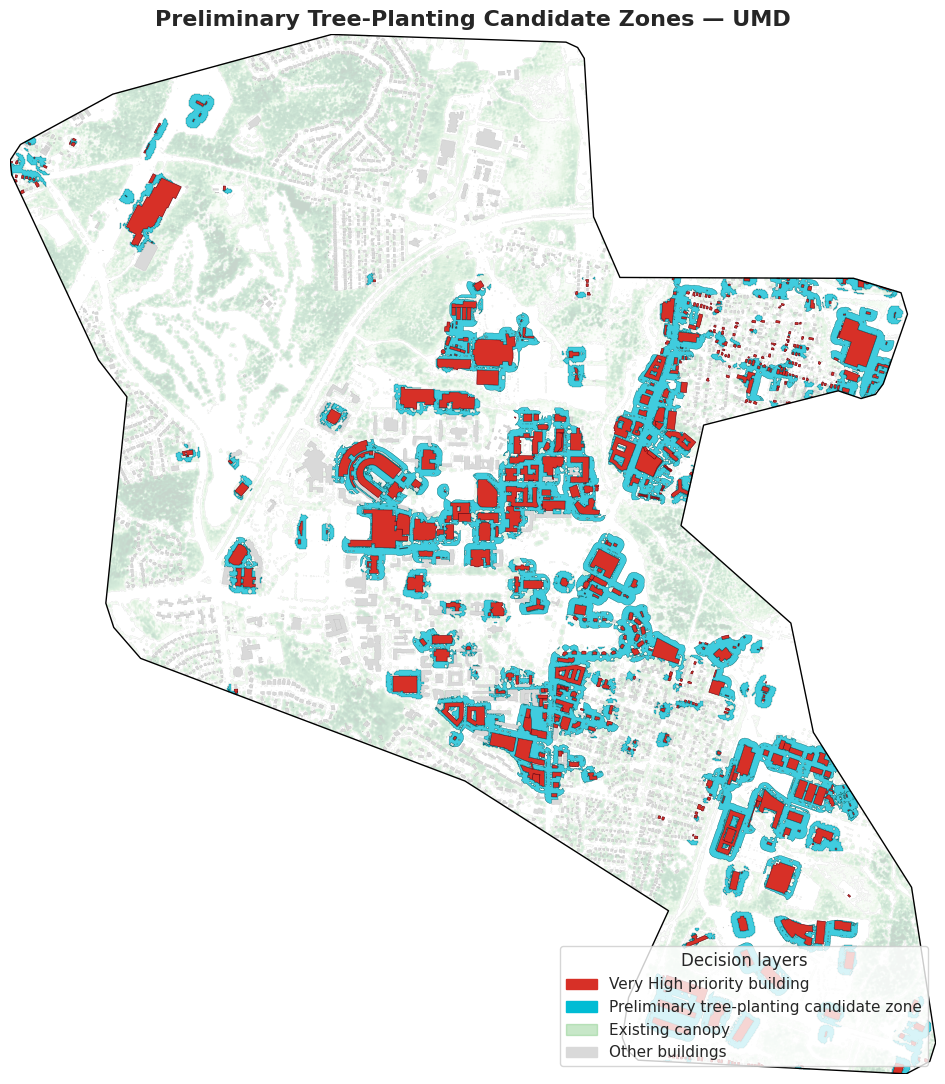


--- TREE-PLANTING SCREENING SUMMARY ---
Priority source buildings: 638
Raw candidate area: 1.26 km²
Candidate zones ≥25 m²: 308
Final candidate-zone area: 1.254 km²

Candidate zones by size:
area_class
Small         105
Medium         94
Very Large     58
Large          51
Name: count, dtype: int64

Largest candidate zones:


,zone_id,area_m2,area_class
162,163,208195.0,Very Large
255,256,166061.0,Very Large
272,273,123649.0,Very Large
142,143,114558.0,Very Large
184,185,54982.0,Very Large
75,76,49126.0,Very Large
77,78,48633.0,Very Large
296,297,47441.0,Very Large
223,224,24048.0,Very Large
174,175,19856.0,Very Large



Created: /content/umd-urban-heat-exposure/data/processed/umd_candidate_tree_planting_zones.geojson
Created: /content/umd-urban-heat-exposure/outputs/figures/umd_candidate_tree_planting_zones.png


In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from rasterio.features import rasterize, shapes
from rasterio.warp import reproject, Resampling
from rasterio.transform import array_bounds
from shapely.geometry import shape


# --------------------------------------------------
# Paths
# --------------------------------------------------
REPO_DIR = Path("/content/umd-urban-heat-exposure")

PRIORITY_PATH = (
    REPO_DIR
    / "data/processed"
    / "umd_building_heat_priority_2026-08-29.geojson"
)

CANOPY_PATH = (
    REPO_DIR
    / "data/processed"
    / "umd_canopy_height_naip_chm_1m.tif"
)

LAI_PATH = (
    REPO_DIR
    / "data/processed"
    / "umd_lai_summer_2026_20m.tif"
)

BOUNDARY_PATH = (
    REPO_DIR
    / "data/umd_boundary_final.geojson"
)

OUTPUT_GEOJSON = (
    REPO_DIR
    / "data/processed"
    / "umd_candidate_tree_planting_zones.geojson"
)

OUTPUT_FIGURE = (
    REPO_DIR
    / "outputs/figures"
    / "umd_candidate_tree_planting_zones.png"
)


# --------------------------------------------------
# Load buildings
# --------------------------------------------------
buildings = (
    gpd.read_file(PRIORITY_PATH)
    .to_crs("EPSG:26918")
)

buildings["footprint_area_m2"] = pd.to_numeric(
    buildings["footprint_area_m2"],
    errors="coerce"
)

lai_threshold = float(
    buildings[
        "surrounding_lai_mean_30m"
    ].quantile(0.25)
)

priority_buildings = buildings[
    (buildings["priority_class"] == "Very High")
    & (buildings["footprint_area_m2"] >= 25)
].copy()

print("Very High buildings:", len(priority_buildings))
print("Low-LAI threshold:", round(lai_threshold, 3))


# --------------------------------------------------
# Reference 1 m grid
# --------------------------------------------------
with rasterio.open(CANOPY_PATH) as src:
    canopy = src.read(1).astype("float32")
    raster_crs = src.crs
    raster_transform = src.transform
    raster_shape = (src.height, src.width)

    west, south, east, north = array_bounds(
        src.height,
        src.width,
        src.transform
    )

canopy_present = (
    np.isfinite(canopy)
    & (canopy >= 2)
    & (canopy <= 60)
)


# --------------------------------------------------
# Reproject LAI to the canopy grid
# --------------------------------------------------
lai_on_grid = np.full(
    raster_shape,
    np.nan,
    dtype="float32"
)

with rasterio.open(LAI_PATH) as src:

    reproject(
        source=rasterio.band(src, 1),
        destination=lai_on_grid,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=raster_transform,
        dst_crs=raster_crs,
        dst_nodata=np.nan,
        resampling=Resampling.bilinear
    )


# --------------------------------------------------
# AOI mask
# --------------------------------------------------
boundary = gpd.read_file(
    BOUNDARY_PATH
).to_crs(raster_crs)

aoi_mask = rasterize(
    [
        (geometry, 1)
        for geometry in boundary.geometry
        if geometry is not None
        and not geometry.is_empty
    ],
    out_shape=raster_shape,
    transform=raster_transform,
    fill=0,
    dtype="uint8",
    all_touched=False
).astype(bool)


# --------------------------------------------------
# Building exclusion mask
# --------------------------------------------------
building_mask = rasterize(
    [
        (geometry, 1)
        for geometry in buildings.geometry
        if geometry is not None
        and not geometry.is_empty
    ],
    out_shape=raster_shape,
    transform=raster_transform,
    fill=0,
    dtype="uint8",
    all_touched=True
).astype(bool)


# --------------------------------------------------
# 30 m priority-building influence zone
# --------------------------------------------------
priority_buffer_geometry = (
    priority_buildings.geometry
    .buffer(30)
    .union_all()
)

priority_buffer_mask = rasterize(
    [(priority_buffer_geometry, 1)],
    out_shape=raster_shape,
    transform=raster_transform,
    fill=0,
    dtype="uint8",
    all_touched=True
).astype(bool)


# --------------------------------------------------
# Candidate planting mask
# --------------------------------------------------
candidate_mask = (
    aoi_mask
    & priority_buffer_mask
    & ~building_mask
    & ~canopy_present
    & np.isfinite(lai_on_grid)
    & (lai_on_grid <= lai_threshold)
)

raw_candidate_area_m2 = int(
    candidate_mask.sum()
)


# --------------------------------------------------
# Convert candidate raster to polygons
# --------------------------------------------------
candidate_geometries = []

for geometry_mapping, value in shapes(
    candidate_mask.astype("uint8"),
    mask=candidate_mask,
    transform=raster_transform
):

    if value != 1:
        continue

    geometry = shape(geometry_mapping)

    if geometry.area >= 25:
        candidate_geometries.append(geometry)


candidate_zones = gpd.GeoDataFrame(
    {
        "zone_id": np.arange(
            1,
            len(candidate_geometries) + 1
        ),
        "screening_method": (
            "Within 30 m of Very High priority building; "
            "low LAI; no canopy; outside buildings"
        ),
        "lai_threshold": lai_threshold,
        "minimum_zone_area_m2": 25
    },
    geometry=candidate_geometries,
    crs=raster_crs
)

if candidate_zones.empty:
    raise ValueError(
        "No candidate planting zones were created."
    )

candidate_zones["area_m2"] = (
    candidate_zones.geometry.area
)

candidate_zones["area_class"] = pd.cut(
    candidate_zones["area_m2"],
    bins=[0, 100, 500, 2000, np.inf],
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ]
).astype(str)

candidate_zones.to_crs(
    "EPSG:4326"
).to_file(
    OUTPUT_GEOJSON,
    driver="GeoJSON"
)


# --------------------------------------------------
# Map
# --------------------------------------------------
canopy_display = np.ma.masked_where(
    canopy < 2,
    canopy
)

extent = [west, east, south, north]

figure, ax = plt.subplots(
    figsize=(11, 11)
)

ax.imshow(
    canopy_display,
    extent=extent,
    origin="upper",
    cmap="Greens",
    vmin=2,
    vmax=30,
    alpha=0.22
)

buildings.plot(
    ax=ax,
    color="#d9d9d9",
    edgecolor="#969696",
    linewidth=0.1
)

priority_buildings.plot(
    ax=ax,
    color="#d73027",
    edgecolor="#67000d",
    linewidth=0.4
)

candidate_zones.plot(
    ax=ax,
    color="#00bcd4",
    edgecolor="#006064",
    linewidth=0.3,
    alpha=0.75
)

boundary.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1
)

legend_items = [
    mpatches.Patch(
        color="#d73027",
        label="Very High priority building"
    ),
    mpatches.Patch(
        color="#00bcd4",
        label="Preliminary tree-planting candidate zone"
    ),
    mpatches.Patch(
        color="#74c476",
        alpha=0.4,
        label="Existing canopy"
    ),
    mpatches.Patch(
        color="#d9d9d9",
        label="Other buildings"
    )
]

ax.legend(
    handles=legend_items,
    loc="lower right",
    title="Decision layers"
)

ax.set_title(
    "Preliminary Tree-Planting Candidate Zones — UMD",
    fontsize=16,
    fontweight="bold"
)

ax.set_axis_off()
ax.set_aspect("equal")

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Summary
# --------------------------------------------------
print("\n--- TREE-PLANTING SCREENING SUMMARY ---")
print("Priority source buildings:", len(priority_buildings))
print("Raw candidate area:", round(raw_candidate_area_m2 / 1_000_000, 3), "km²")
print("Candidate zones ≥25 m²:", len(candidate_zones))
print(
    "Final candidate-zone area:",
    round(candidate_zones["area_m2"].sum() / 1_000_000, 3),
    "km²"
)

print("\nCandidate zones by size:")
print(candidate_zones["area_class"].value_counts())

print("\nLargest candidate zones:")
display(
    candidate_zones[
        ["zone_id", "area_m2", "area_class"]
    ]
    .sort_values(
        "area_m2",
        ascending=False
    )
    .head(15)
)

print("\nCreated:", OUTPUT_GEOJSON)
print("Created:", OUTPUT_FIGURE)

In [27]:
from pathlib import Path
from shutil import copy2
import subprocess

from google.colab import drive

drive.mount("/content/drive")

REPO_DIR = Path("/content/umd-urban-heat-exposure")
DRIVE_BACKUP = (
    Path("/content/drive/MyDrive/FortyGuard")
    / "umd-urban-heat-exposure"
)

FILES = [
    "data/processed/umd_fortyguard_temperature_60m_2026-08-29.geojson",
    "data/processed/umd_building_temperature_exposure_2026-08-29.geojson",
    "data/processed/umd_building_temperature_exposure_2026-08-29.csv",
    "data/processed/umd_temperature_exposure_correlations_2026-08-29.csv",
    "data/processed/umd_building_heat_analysis_2026-08-29.geojson",
    "data/processed/umd_building_heat_analysis_2026-08-29.csv",
    "data/processed/umd_building_heat_priority_2026-08-29.geojson",
    "data/processed/umd_building_heat_priority_2026-08-29.csv",
    "data/processed/umd_candidate_tree_planting_zones.geojson",
    "outputs/figures/umd_temperature_relationships.png",
    "outputs/figures/umd_heat_priority_hotspots.png",
    "outputs/figures/umd_candidate_tree_planting_zones.png",
]

existing_files = []

print("--- BACKUP ---")

for relative_name in FILES:
    source = REPO_DIR / relative_name

    if not source.exists():
        print("Missing:", relative_name)
        continue

    destination = DRIVE_BACKUP / relative_name
    destination.parent.mkdir(parents=True, exist_ok=True)
    copy2(source, destination)

    existing_files.append(relative_name)
    print("Copied:", relative_name)

if not existing_files:
    raise RuntimeError("No Notebook 6 outputs were found.")

print("\n--- GIT COMMIT ---")

subprocess.run(
    ["git", "add", "-f", *existing_files],
    cwd=REPO_DIR,
    check=True
)

status = subprocess.run(
    ["git", "status", "--short"],
    cwd=REPO_DIR,
    check=True,
    capture_output=True,
    text=True
)

print(status.stdout)

has_staged_changes = subprocess.run(
    ["git", "diff", "--cached", "--quiet"],
    cwd=REPO_DIR
).returncode != 0

if has_staged_changes:
    subprocess.run(
        [
            "git",
            "commit",
            "-m",
            "Add FortyGuard heat analysis and planting priorities"
        ],
        cwd=REPO_DIR,
        check=True
    )
else:
    print("No new output changes to commit.")

subprocess.run(
    ["git", "pull", "--rebase", "origin", "main"],
    cwd=REPO_DIR,
    check=True
)

subprocess.run(
    ["git", "push", "origin", "main"],
    cwd=REPO_DIR,
    check=True
)

print("\nNotebook 6 outputs backed up and uploaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- BACKUP ---
Copied: data/processed/umd_fortyguard_temperature_60m_2026-08-29.geojson
Copied: data/processed/umd_building_temperature_exposure_2026-08-29.geojson
Copied: data/processed/umd_building_temperature_exposure_2026-08-29.csv
Copied: data/processed/umd_temperature_exposure_correlations_2026-08-29.csv
Copied: data/processed/umd_building_heat_analysis_2026-08-29.geojson
Copied: data/processed/umd_building_heat_analysis_2026-08-29.csv
Copied: data/processed/umd_building_heat_priority_2026-08-29.geojson
Copied: data/processed/umd_building_heat_priority_2026-08-29.csv
Copied: data/processed/umd_candidate_tree_planting_zones.geojson
Copied: outputs/figures/umd_temperature_relationships.png
Copied: outputs/figures/umd_heat_priority_hotspots.png
Copied: outputs/figures/umd_candidate_tree_planting_zones.png

--- GIT COMMIT ---
?? data/raw/

No new output cha

CalledProcessError: Command '['git', 'push', 'origin', 'main']' returned non-zero exit status 128.

In [28]:
from pathlib import Path
import subprocess

REPO_DIR = Path("/content/umd-urban-heat-exposure")

# Reuse identity from the repository's previous commit
git_name = subprocess.run(
    ["git", "log", "-1", "--format=%an"],
    cwd=REPO_DIR,
    capture_output=True,
    text=True,
    check=True
).stdout.strip()

git_email = subprocess.run(
    ["git", "log", "-1", "--format=%ae"],
    cwd=REPO_DIR,
    capture_output=True,
    text=True,
    check=True
).stdout.strip()

subprocess.run(
    ["git", "config", "user.name", git_name],
    cwd=REPO_DIR,
    check=True
)

subprocess.run(
    ["git", "config", "user.email", git_email],
    cwd=REPO_DIR,
    check=True
)

print("Git identity:", git_name, git_email)

commit = subprocess.run(
    [
        "git",
        "commit",
        "-m",
        "Add FortyGuard heat analysis and planting priorities"
    ],
    cwd=REPO_DIR,
    capture_output=True,
    text=True
)

print(commit.stdout)
print(commit.stderr)

if commit.returncode != 0:
    raise RuntimeError("Git commit still failed. Check the message above.")

subprocess.run(
    ["git", "pull", "--rebase", "origin", "main"],
    cwd=REPO_DIR,
    check=True
)

subprocess.run(
    ["git", "push", "origin", "main"],
    cwd=REPO_DIR,
    check=True
)

print("Successfully uploaded Notebook 6 outputs.")

Git identity: hayatkhan20 hayatkhan20@users.noreply.github.com
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/raw/

nothing added to commit but untracked files present (use "git add" to track)




RuntimeError: Git commit still failed. Check the message above.

In [29]:
from pathlib import Path
from google.colab import userdata

import base64
import subprocess

REPO_DIR = Path("/content/umd-urban-heat-exposure")

token = userdata.get("GITHUB_TOKEN")

if not token:
    raise ValueError(
        "Add your GitHub token to Colab Secrets as GITHUB_TOKEN."
    )

credentials = base64.b64encode(
    f"x-access-token:{token}".encode()
).decode()

push = subprocess.run(
    [
        "git",
        "-c",
        f"http.extraHeader=Authorization: Basic {credentials}",
        "push",
        "origin",
        "main"
    ],
    cwd=REPO_DIR,
    capture_output=True,
    text=True
)

print(push.stdout)
print(push.stderr)

if push.returncode != 0:
    raise RuntimeError("GitHub push failed. Read the message above.")

print("Successfully uploaded commit 2736405 to GitHub.")


To https://github.com/hayatkhan20/umd-urban-heat-exposure.git
   32b66a7..a8db51a  main -> main

Successfully uploaded commit 2736405 to GitHub.
